# Test EDA — construcción paso a paso de `eda.py`

Este notebook sirve para **probar y construir paso a paso** el archivo final `eda.py`.



In [6]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GENERAL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import FuncFormatter
from IPython.display import display

# Rutas relativas desde la carpeta notebooks/
ruta_data_limpios = Path(r"..\data_limpios")
ruta_graficos = Path(r"..\graficos")
ruta_graficos.mkdir(parents=True, exist_ok=True)



In [7]:
# ============================================================
# 2. CONFIGURACIÓN VISUAL DE LOS GRÁFICOS
# ============================================================

plt.style.use("dark_background")

COLOR_FONDO   = "#111827"
COLOR_PANEL   = "#1f2937"
COLOR_TEXTO   = "#f9fafb"
COLOR_GRID    = "#6b7280"
COLOR_CONSUMO = "#38bdf8"
COLOR_COSTE   = "#f97316"
COLOR_TEMP    = "#facc15"
COLOR_VIENTO  = "#a78bfa"

ORDEN_PERIODOS = ["P1", "P2", "P3", "P4", "P5", "P6"]
ORDEN_TURNOS   = ["M", "T", "N"]

COLORES_PERIODOS = {
    "P1": "#ef4444",
    "P2": "#f97316",
    "P3": "#facc15",
    "P4": "#22c55e",
    "P5": "#14b8a6",
    "P6": "#3b82f6"
}

COLORES_TURNOS = {
    "M": "#38bdf8",
    "T": "#facc15",
    "N": "#a78bfa"
}

ETIQUETAS_TURNOS = {
    "M": "Mañana\n06-14h",
    "T": "Tarde\n14-22h",
    "N": "Noche\n22-06h"
}


def aplicar_estilo(ax):
    """Aplica el estilo visual común a todos los gráficos."""
    ax.set_facecolor(COLOR_PANEL)
    ax.grid(True, alpha=0.22, color=COLOR_GRID)
    ax.tick_params(colors=COLOR_TEXTO)
    ax.xaxis.label.set_color(COLOR_TEXTO)
    ax.yaxis.label.set_color(COLOR_TEXTO)
    ax.title.set_color(COLOR_TEXTO)
    for spine in ax.spines.values():
        spine.set_color("#374151")


def guardar_y_mostrar_grafico(nombre_archivo):
    """Guarda el gráfico y lo muestra en el notebook."""
    plt.tight_layout()
    plt.savefig(
        ruta_graficos / nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


def formato_miles(x, pos):
    return f"{x:,.0f}"


def formato_eur_kwh(x, pos):
    return f"{x:.3f}"

print("Configuración visual cargada correctamente.")

Configuración visual cargada correctamente.


## 1. Carga y revisión inicial de datasets

Primero se cargan los dos datasets que utiliza `eda.py`:

- `df_maestro.csv`: dataset principal del EDA.
- `df_clima_2024_limpio.csv`: dataset climático diario.

In [8]:
# ============================================================
# 3. CARGA DE DATOS
# ============================================================

df_maestro = pd.read_csv(ruta_data_limpios / "df_maestro.csv")
df_clima = pd.read_csv(ruta_data_limpios / "df_clima_2024_limpio.csv")

print("df_maestro cargado:", df_maestro.shape)
print("df_clima cargado:", df_clima.shape)

df_maestro cargado: (8784, 36)
df_clima cargado: (366, 15)


In [9]:
# ============================================================
# 4. REVISIÓN INICIAL DE DF_MAESTRO
# ============================================================

print("Primeras filas de df_maestro:")
display(df_maestro.head())

print("\nInformación general de df_maestro:")
df_maestro.info()

Primeras filas de df_maestro:


,datetime_hora,fecha,dia,mes,mes_nombre,dia_semana_2024,tipo_semana,hora_periodo,turno,periodo_tarifario,...,reactiva_080_eur_kvarh,iee_perc,iva_perc,alq_trif_eur_dia,bs_eur_dia,fnee_eur_kwh,tasa_mun_perc,precio_variable_parcial_eur_kwh,coste_estimado_parcial_eur,semana_anio
0,2024-01-01 00:00:00,2024-01-01,1,1,Enero,Monday,Weekday,1,N,P6,...,0.062332,2.5,21,0.04471,0.00626,0.00097,1.5,0.00334,0.046192,1
1,2024-01-01 01:00:00,2024-01-01,1,1,Enero,Monday,Weekday,2,N,P6,...,0.062332,2.5,21,0.04471,0.00626,0.00097,1.5,0.00334,0.046793,1
2,2024-01-01 02:00:00,2024-01-01,1,1,Enero,Monday,Weekday,3,N,P6,...,0.062332,2.5,21,0.04471,0.00626,0.00097,1.5,0.00334,0.047161,1
3,2024-01-01 03:00:00,2024-01-01,1,1,Enero,Monday,Weekday,4,N,P6,...,0.062332,2.5,21,0.04471,0.00626,0.00097,1.5,0.00334,0.046159,1
4,2024-01-01 04:00:00,2024-01-01,1,1,Enero,Monday,Weekday,5,N,P6,...,0.062332,2.5,21,0.04471,0.00626,0.00097,1.5,0.00334,0.048330,1



Información general de df_maestro:
<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   datetime_hora                    8784 non-null   str    
 1   fecha                            8784 non-null   str    
 2   dia                              8784 non-null   int64  
 3   mes                              8784 non-null   int64  
 4   mes_nombre                       8784 non-null   str    
 5   dia_semana_2024                  8784 non-null   str    
 6   tipo_semana                      8784 non-null   str    
 7   hora_periodo                     8784 non-null   int64  
 8   turno                            8784 non-null   str    
 9   periodo_tarifario                8784 non-null   str    
 10  tramo_horario                    8784 non-null   str    
 11  hora_inicio                      8784 non-null   int64  


In [10]:
# ============================================================
# 5. REVISIÓN INICIAL DE DF_CLIMA
# ============================================================

print("Primeras filas de df_clima:")
display(df_clima.head())

print("\nInformación general de df_clima:")
df_clima.info()

Primeras filas de df_clima:


,fecha,dia,mes,dia_semana,dia_anio,temperatura_media,temperatura_minima,temperatura_maxima,precipitacion,viento_medio,racha_viento,horas_sol,presion_maxima,presion_minima,num_estaciones
0,2024-01-01,1,1,Monday,1,9.172331,4.658898,13.689437,0.090636,1.925455,7.419161,5.417361,964.165766,960.009009,888
1,2024-01-02,2,1,Tuesday,2,10.257768,5.570656,14.947126,3.706025,3.062378,10.564846,3.106164,964.392308,960.030769,887
2,2024-01-03,3,1,Wednesday,3,11.894286,7.892229,15.895200,0.791782,2.421250,8.755000,2.678621,963.016592,959.357399,890
3,2024-01-04,4,1,Thursday,4,10.535624,6.846506,14.220848,5.277468,2.121419,9.188424,2.255782,962.065766,953.613514,892
4,2024-01-05,5,1,Friday,5,8.337729,5.485682,11.198968,5.581503,3.571727,11.899580,3.462069,957.626457,951.178027,892



Información general de df_clima:
<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               366 non-null    str    
 1   dia                 366 non-null    int64  
 2   mes                 366 non-null    int64  
 3   dia_semana          366 non-null    str    
 4   dia_anio            366 non-null    int64  
 5   temperatura_media   366 non-null    float64
 6   temperatura_minima  366 non-null    float64
 7   temperatura_maxima  366 non-null    float64
 8   precipitacion       366 non-null    float64
 9   viento_medio        366 non-null    float64
 10  racha_viento        366 non-null    float64
 11  horas_sol           366 non-null    float64
 12  presion_maxima      366 non-null    float64
 13  presion_minima      366 non-null    float64
 14  num_estaciones      366 non-null    int64  
dtypes: float64(9), int64(4), str(2)
me

In [11]:
# ============================================================
# 6. CONVERSIÓN DE FECHAS Y ORDENACIÓN
# ============================================================

# Al leer desde CSV, las fechas entran como texto.
# Para agrupar por día, calcular series temporales y ordenar correctamente,
# las convertimos a datetime.

df_maestro["datetime_hora"] = pd.to_datetime(df_maestro["datetime_hora"])
df_maestro["fecha"] = pd.to_datetime(df_maestro["fecha"])
df_clima["fecha"] = pd.to_datetime(df_clima["fecha"])

df_maestro = (
    df_maestro
    .sort_values("datetime_hora")
    .reset_index(drop=True)
)

print("Fechas convertidas correctamente.")
print("Rango df_maestro:", df_maestro["datetime_hora"].min(), "→", df_maestro["datetime_hora"].max())
print("Rango df_clima:", df_clima["fecha"].min(), "→", df_clima["fecha"].max())

Fechas convertidas correctamente.
Rango df_maestro: 2024-01-01 00:00:00 → 2024-12-31 23:00:00
Rango df_clima: 2024-01-01 00:00:00 → 2024-12-31 00:00:00


In [12]:
# ============================================================
# 7. VALIDACIÓN DE COLUMNAS CLAVE Y CATEGORÍAS
# ============================================================

columnas_necesarias = [
    "datetime_hora", "fecha", "mes", "hora_periodo", "turno",
    "periodo_tarifario", "consumo_kwh", "potencia_media_kw",
    "coste_estimado_parcial_eur", "precio_variable_parcial_eur_kwh"
]

faltantes = [col for col in columnas_necesarias if col not in df_maestro.columns]

if len(faltantes) == 0:
    print("OK: todas las columnas clave están en df_maestro.")
else:
    print("Faltan columnas:", faltantes)

# Ordenamos categorías para que los gráficos salgan siempre en el mismo orden.
df_maestro["periodo_tarifario"] = pd.Categorical(
    df_maestro["periodo_tarifario"],
    categories=ORDEN_PERIODOS,
    ordered=True
)

df_maestro["turno"] = pd.Categorical(
    df_maestro["turno"],
    categories=ORDEN_TURNOS,
    ordered=True
)

print("\nPeriodos tarifarios:")
print(df_maestro["periodo_tarifario"].value_counts().sort_index())

print("\nTurnos:")
print(df_maestro["turno"].value_counts().sort_index())

OK: todas las columnas clave están en df_maestro.

Periodos tarifarios:
periodo_tarifario
P1     801
P2    1001
P3     861
P4    1053
P5     476
P6    4592
Name: count, dtype: int64

Turnos:
turno
M    2928
T    2928
N    2928
Name: count, dtype: int64


In [13]:
# ============================================================
# 8. VALIDACIONES BÁSICAS DEL DATASET MAESTRO
# ============================================================

print("Filas df_maestro:", len(df_maestro))
print("Días únicos:", df_maestro["fecha"].nunique())
print("Horas por día:")
print(df_maestro.groupby("fecha").size().value_counts().sort_index())

print("\nNulos en columnas principales:")
display(df_maestro[columnas_necesarias].isna().sum())

print("\nConsumo total anual (kWh):", round(df_maestro["consumo_kwh"].sum(), 2))
print("Coste estimado total (€):", round(df_maestro["coste_estimado_parcial_eur"].sum(), 2))

Filas df_maestro: 8784
Días únicos: 366
Horas por día:
24    366
Name: count, dtype: int64

Nulos en columnas principales:


datetime_hora                      0
fecha                              0
mes                                0
hora_periodo                       0
turno                              0
periodo_tarifario                  0
consumo_kwh                        0
potencia_media_kw                  0
coste_estimado_parcial_eur         0
precio_variable_parcial_eur_kwh    0
dtype: int64


Consumo total anual (kWh): 959988.57
Coste estimado total (€): 20222.56


## H1. Clima, consumo y coste estimado

**Hipótesis:** el consumo eléctrico diario puede variar en función de la temperatura exterior, especialmente en días de frío o calor intenso.

In [14]:
# ============================================================
# H1.1 - AGREGACIÓN DEL CONSUMO HORARIO A NIVEL DIARIO
# ============================================================

df_consumo_diario = (
    df_maestro
    .groupby("fecha", as_index=False)
    .agg(
        dia=("dia", "first"),
        mes=("mes", "first"),
        mes_nombre=("mes_nombre", "first"),
        dia_semana_2024=("dia_semana_2024", "first"),
        tipo_semana=("tipo_semana", "first"),
        consumo_kwh=("consumo_kwh", "sum"),
        coste_estimado_parcial_eur=("coste_estimado_parcial_eur", "sum"),
        potencia_media_diaria_kw=("potencia_media_kw", "mean"),
        potencia_max_horaria_kw=("potencia_media_kw", "max"),
        reactiva_retrasada_kvarh=("reactiva_retrasada_kvarh", "sum"),
        reactiva_adelantada_kvarh=("reactiva_adelantada_kvarh", "sum"),
        CO2_tCO2=("CO2(tCO2)", "sum"),
        factor_potencia_retrasada=("factor_potencia_retrasada", "mean"),
        factor_potencia_adelantada=("factor_potencia_adelantada", "mean")
    )
)

df_consumo_diario["coste_unitario_parcial_eur_kwh"] = (
    df_consumo_diario["coste_estimado_parcial_eur"]
    / df_consumo_diario["consumo_kwh"]
)

print("df_consumo_diario creado:", df_consumo_diario.shape)
print("Días únicos:", df_consumo_diario["fecha"].nunique())
print("Consumo diario total:", round(df_consumo_diario["consumo_kwh"].sum(), 2))
print("Diferencia contra df_maestro:", round(df_consumo_diario["consumo_kwh"].sum() - df_maestro["consumo_kwh"].sum(), 6))

display(df_consumo_diario.head())

df_consumo_diario creado: (366, 16)
Días únicos: 366
Consumo diario total: 959988.57
Diferencia contra df_maestro: 0.0


,fecha,dia,mes,mes_nombre,dia_semana_2024,tipo_semana,consumo_kwh,coste_estimado_parcial_eur,potencia_media_diaria_kw,potencia_max_horaria_kw,reactiva_retrasada_kvarh,reactiva_adelantada_kvarh,CO2_tCO2,factor_potencia_retrasada,factor_potencia_adelantada,coste_unitario_parcial_eur_kwh
0,2024-01-01,1,1,Enero,Monday,Weekday,351.86,10.272602,14.660833,15.80,166.62,948.96,0.00,85.299375,57.076146,0.029195
1,2024-01-02,2,1,Enero,Tuesday,Weekday,3950.43,154.680507,164.601250,498.93,1579.63,294.06,0.00,84.207292,92.138125,0.039155
2,2024-01-03,3,1,Enero,Wednesday,Weekday,3561.05,138.949945,148.377083,485.53,1285.59,265.59,1.53,86.100000,92.617292,0.039019
3,2024-01-04,4,1,Enero,Thursday,Weekday,4977.72,198.352825,207.405000,528.08,2059.11,224.57,2.17,84.128125,93.423750,0.039848
4,2024-01-05,5,1,Enero,Friday,Weekday,4683.40,187.380452,195.141667,495.58,1960.60,258.16,2.04,84.063021,92.862813,0.040009


In [15]:
# ============================================================
# H1.2 - UNIÓN CON CLIMA
# ============================================================

columnas_clima = [
    "fecha",
    "temperatura_media",
    "temperatura_minima",
    "temperatura_maxima",
    "precipitacion",
    "viento_medio",
    "racha_viento",
    "horas_sol",
    "presion_maxima",
    "presion_minima",
    "num_estaciones"
]

df_consumo_clima = df_consumo_diario.merge(
    df_clima[columnas_clima],
    on="fecha",
    how="left"
)

print("df_consumo_clima creado:", df_consumo_clima.shape)
print("Nulos en variables climáticas:")
display(df_consumo_clima[columnas_clima].isna().sum())

display(df_consumo_clima.head())

df_consumo_clima creado: (366, 26)
Nulos en variables climáticas:


fecha                 0
temperatura_media     0
temperatura_minima    0
temperatura_maxima    0
precipitacion         0
viento_medio          0
racha_viento          0
horas_sol             0
presion_maxima        0
presion_minima        0
num_estaciones        0
dtype: int64

,fecha,dia,mes,mes_nombre,dia_semana_2024,tipo_semana,consumo_kwh,coste_estimado_parcial_eur,potencia_media_diaria_kw,potencia_max_horaria_kw,...,temperatura_media,temperatura_minima,temperatura_maxima,precipitacion,viento_medio,racha_viento,horas_sol,presion_maxima,presion_minima,num_estaciones
0,2024-01-01,1,1,Enero,Monday,Weekday,351.86,10.272602,14.660833,15.80,...,9.172331,4.658898,13.689437,0.090636,1.925455,7.419161,5.417361,964.165766,960.009009,888
1,2024-01-02,2,1,Enero,Tuesday,Weekday,3950.43,154.680507,164.601250,498.93,...,10.257768,5.570656,14.947126,3.706025,3.062378,10.564846,3.106164,964.392308,960.030769,887
2,2024-01-03,3,1,Enero,Wednesday,Weekday,3561.05,138.949945,148.377083,485.53,...,11.894286,7.892229,15.895200,0.791782,2.421250,8.755000,2.678621,963.016592,959.357399,890
3,2024-01-04,4,1,Enero,Thursday,Weekday,4977.72,198.352825,207.405000,528.08,...,10.535624,6.846506,14.220848,5.277468,2.121419,9.188424,2.255782,962.065766,953.613514,892
4,2024-01-05,5,1,Enero,Friday,Weekday,4683.40,187.380452,195.141667,495.58,...,8.337729,5.485682,11.198968,5.581503,3.571727,11.899580,3.462069,957.626457,951.178027,892


In [16]:
# ============================================================
# H1.3 - CREACIÓN DE VARIABLES CLIMÁTICAS AUXILIARES
# ============================================================

def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return "Invierno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verano"
    else:
        return "Otoño"


df_consumo_clima["estacion"] = df_consumo_clima["mes"].apply(asignar_estacion)

p10_temp = df_consumo_clima["temperatura_media"].quantile(0.10)
p90_temp = df_consumo_clima["temperatura_media"].quantile(0.90)


def clasificar_temperatura(temp):
    if temp <= p10_temp:
        return "Frío"
    elif temp >= p90_temp:
        return "Caluroso"
    else:
        return "Normal"


df_consumo_clima["tipo_temperatura"] = (
    df_consumo_clima["temperatura_media"].apply(clasificar_temperatura)
)

print("Percentil 10 temperatura:", round(p10_temp, 2))
print("Percentil 90 temperatura:", round(p90_temp, 2))

print("\nDías por estación:")
print(df_consumo_clima["estacion"].value_counts())

print("\nDías por tipo de temperatura:")
print(df_consumo_clima["tipo_temperatura"].value_counts())

display(df_consumo_clima[["fecha", "temperatura_media", "tipo_temperatura", "estacion", "consumo_kwh", "coste_estimado_parcial_eur"]].head())

Percentil 10 temperatura: 8.95
Percentil 90 temperatura: 23.96

Días por estación:
estacion
Primavera    92
Verano       92
Invierno     91
Otoño        91
Name: count, dtype: int64

Días por tipo de temperatura:
tipo_temperatura
Normal      292
Frío         37
Caluroso     37
Name: count, dtype: int64


,fecha,temperatura_media,tipo_temperatura,estacion,consumo_kwh,coste_estimado_parcial_eur
0,2024-01-01,9.172331,Normal,Invierno,351.86,10.272602
1,2024-01-02,10.257768,Normal,Invierno,3950.43,154.680507
2,2024-01-03,11.894286,Normal,Invierno,3561.05,138.949945
3,2024-01-04,10.535624,Normal,Invierno,4977.72,198.352825
4,2024-01-05,8.337729,Frío,Invierno,4683.40,187.380452


In [17]:
# ============================================================
# H1.4 - GUARDADO DE DF_CONSUMO_CLIMA_LIMPIO
# ============================================================

df_consumo_clima.to_csv(
    ruta_data_limpios / "df_consumo_clima_limpio.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivo generado: df_consumo_clima_limpio.csv")

Archivo generado: df_consumo_clima_limpio.csv


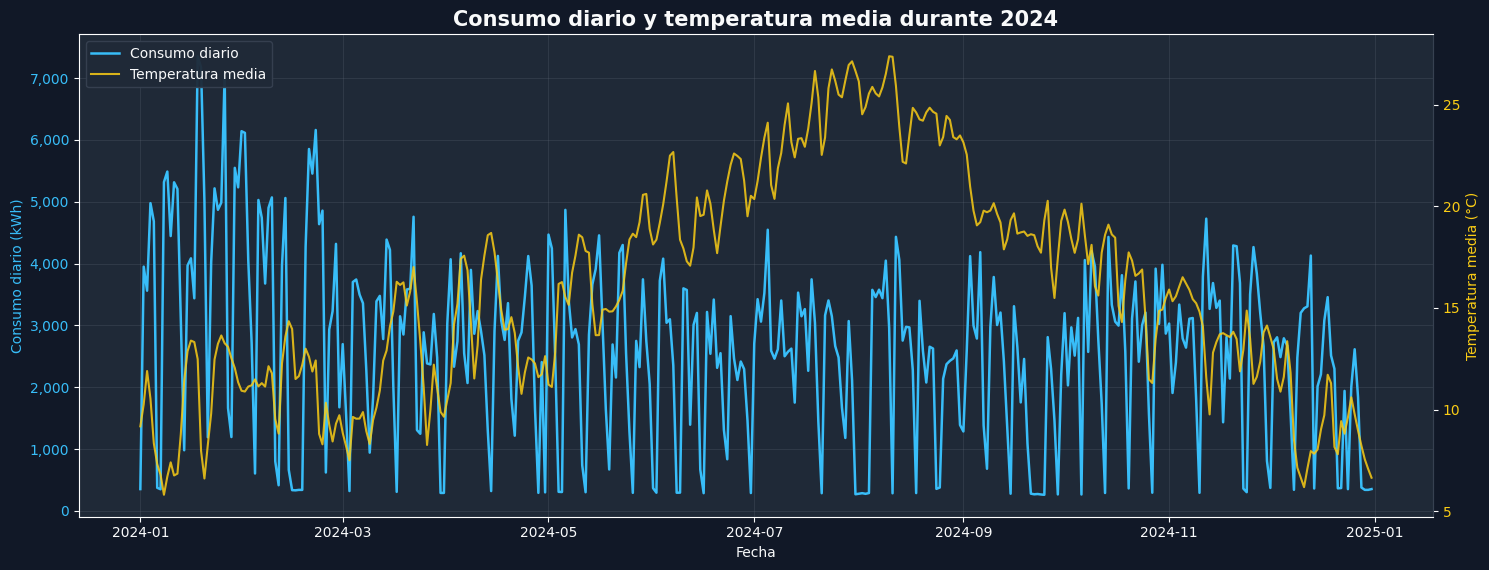

In [18]:
# ============================================================
# H1.5 - GRÁFICO: CONSUMO DIARIO Y TEMPERATURA MEDIA
# ============================================================

fig, ax1 = plt.subplots(figsize=(15, 5.8))
fig.patch.set_facecolor(COLOR_FONDO)

ax1.plot(
    df_consumo_clima["fecha"],
    df_consumo_clima["consumo_kwh"],
    color=COLOR_CONSUMO,
    linewidth=1.8,
    label="Consumo diario"
)

aplicar_estilo(ax1)

ax1.set_title("Consumo diario y temperatura media durante 2024", fontsize=15, weight="bold")
ax1.set_xlabel("Fecha")
ax1.set_ylabel("Consumo diario (kWh)", color=COLOR_CONSUMO)
ax1.tick_params(axis="y", labelcolor=COLOR_CONSUMO)
ax1.yaxis.set_major_formatter(FuncFormatter(formato_miles))

ax2 = ax1.twinx()
ax2.plot(
    df_consumo_clima["fecha"],
    df_consumo_clima["temperatura_media"],
    color=COLOR_TEMP,
    linewidth=1.5,
    alpha=0.85,
    label="Temperatura media"
)

ax2.set_ylabel("Temperatura media (°C)", color=COLOR_TEMP)
ax2.tick_params(axis="y", labelcolor=COLOR_TEMP)
ax2.spines["right"].set_color("#374151")

lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lineas_1 + lineas_2,
    etiquetas_1 + etiquetas_2,
    facecolor=COLOR_PANEL,
    edgecolor="#374151",
    framealpha=0.95,
    loc="upper left"
)

plt.setp(legend.get_texts(), color=COLOR_TEXTO)

guardar_y_mostrar_grafico("h1_01_consumo_diario_temperatura_media.png")

Pendiente de la tendencia lineal: -38.6107
Intercepto: 3239.1723


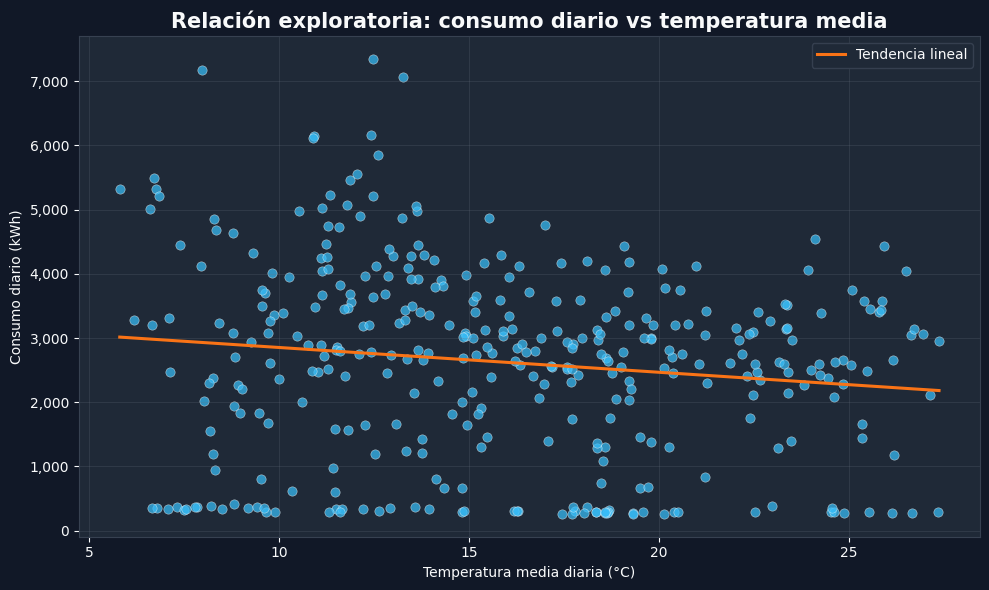

In [19]:
# ============================================================
# H1.6 - GRÁFICO: SCATTER CONSUMO VS TEMPERATURA
# ============================================================

df_h1_temp = df_consumo_clima[["temperatura_media", "consumo_kwh"]].dropna().copy()

x_temp = df_h1_temp["temperatura_media"]
y_consumo = df_h1_temp["consumo_kwh"]

pendiente, intercepto = np.polyfit(x_temp, y_consumo, 1)
x_linea = np.linspace(x_temp.min(), x_temp.max(), 100)
y_linea = pendiente * x_linea + intercepto

print("Pendiente de la tendencia lineal:", round(pendiente, 4))
print("Intercepto:", round(intercepto, 4))

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(COLOR_FONDO)

ax.scatter(
    x_temp,
    y_consumo,
    s=45,
    alpha=0.72,
    color=COLOR_CONSUMO,
    edgecolors="white",
    linewidths=0.35
)

ax.plot(
    x_linea,
    y_linea,
    color=COLOR_COSTE,
    linewidth=2.2,
    label="Tendencia lineal"
)

aplicar_estilo(ax)

ax.set_title("Relación exploratoria: consumo diario vs temperatura media", fontsize=15, weight="bold")
ax.set_xlabel("Temperatura media diaria (°C)")
ax.set_ylabel("Consumo diario (kWh)")
ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))

legend = ax.legend(facecolor=COLOR_PANEL, edgecolor="#374151", framealpha=0.95)
plt.setp(legend.get_texts(), color=COLOR_TEXTO)

guardar_y_mostrar_grafico("h1_02_scatter_consumo_temperatura_media.png")

Resumen por tipo de temperatura:


,tipo_temperatura,dias,temperatura_media,consumo_medio_diario_kwh,coste_medio_diario_eur,coste_unitario_medio_eur_kwh,viento_medio
1,Frío,37,7.719,2595.983,77.248,0.022,2.910
2,Normal,292,15.798,2664.847,52.714,0.016,2.804
0,Caluroso,37,25.485,2318.968,53.293,0.019,2.794


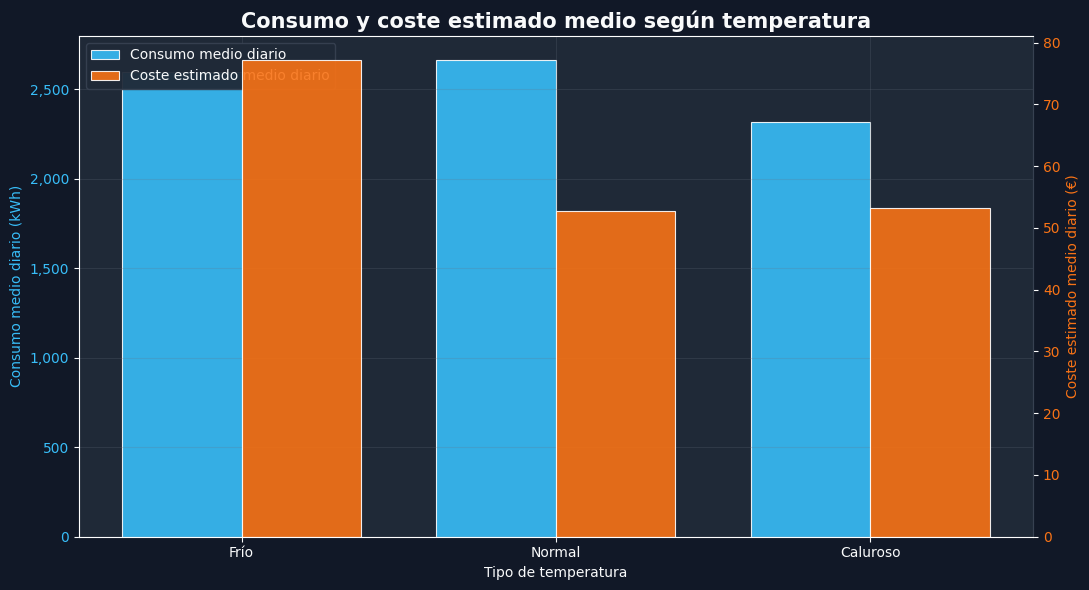

In [20]:
# ============================================================
# H1.7 - GRÁFICO: CONSUMO Y COSTE POR TIPO DE TEMPERATURA
# ============================================================

orden_temp = ["Frío", "Normal", "Caluroso"]

resumen_temp = (
    df_consumo_clima
    .groupby("tipo_temperatura", as_index=False)
    .agg(
        dias=("fecha", "count"),
        temperatura_media=("temperatura_media", "mean"),
        consumo_medio_diario_kwh=("consumo_kwh", "mean"),
        coste_medio_diario_eur=("coste_estimado_parcial_eur", "mean"),
        coste_unitario_medio_eur_kwh=("coste_unitario_parcial_eur_kwh", "mean"),
        viento_medio=("viento_medio", "mean")
    )
)

resumen_temp["tipo_temperatura"] = pd.Categorical(
    resumen_temp["tipo_temperatura"],
    categories=orden_temp,
    ordered=True
)

resumen_temp = resumen_temp.sort_values("tipo_temperatura")

print("Resumen por tipo de temperatura:")
display(resumen_temp.round(3))

x = np.arange(len(resumen_temp))
ancho = 0.38

fig, ax1 = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COLOR_FONDO)

barras_consumo = ax1.bar(
    x - ancho / 2,
    resumen_temp["consumo_medio_diario_kwh"],
    width=ancho,
    color=COLOR_CONSUMO,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    label="Consumo medio diario"
)

aplicar_estilo(ax1)

ax1.set_ylabel("Consumo medio diario (kWh)", color=COLOR_CONSUMO)
ax1.tick_params(axis="y", labelcolor=COLOR_CONSUMO)
ax1.yaxis.set_major_formatter(FuncFormatter(formato_miles))

ax2 = ax1.twinx()
barras_coste = ax2.bar(
    x + ancho / 2,
    resumen_temp["coste_medio_diario_eur"],
    width=ancho,
    color=COLOR_COSTE,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    label="Coste estimado medio diario"
)

ax2.set_ylabel("Coste estimado medio diario (€)", color=COLOR_COSTE)
ax2.tick_params(axis="y", labelcolor=COLOR_COSTE)
ax2.spines["right"].set_color("#374151")

ax1.set_xticks(x)
ax1.set_xticklabels(resumen_temp["tipo_temperatura"])
ax1.set_xlabel("Tipo de temperatura")
ax1.set_title("Consumo y coste estimado medio según temperatura", fontsize=15, weight="bold")

lineas_1, etiquetas_1 = ax1.get_legend_handles_labels()
lineas_2, etiquetas_2 = ax2.get_legend_handles_labels()
legend = ax1.legend(
    lineas_1 + lineas_2,
    etiquetas_1 + etiquetas_2,
    facecolor=COLOR_PANEL,
    edgecolor="#374151",
    framealpha=0.95,
    loc="upper left"
)
plt.setp(legend.get_texts(), color=COLOR_TEXTO)

guardar_y_mostrar_grafico("h1_03_consumo_coste_por_tipo_temperatura.png")

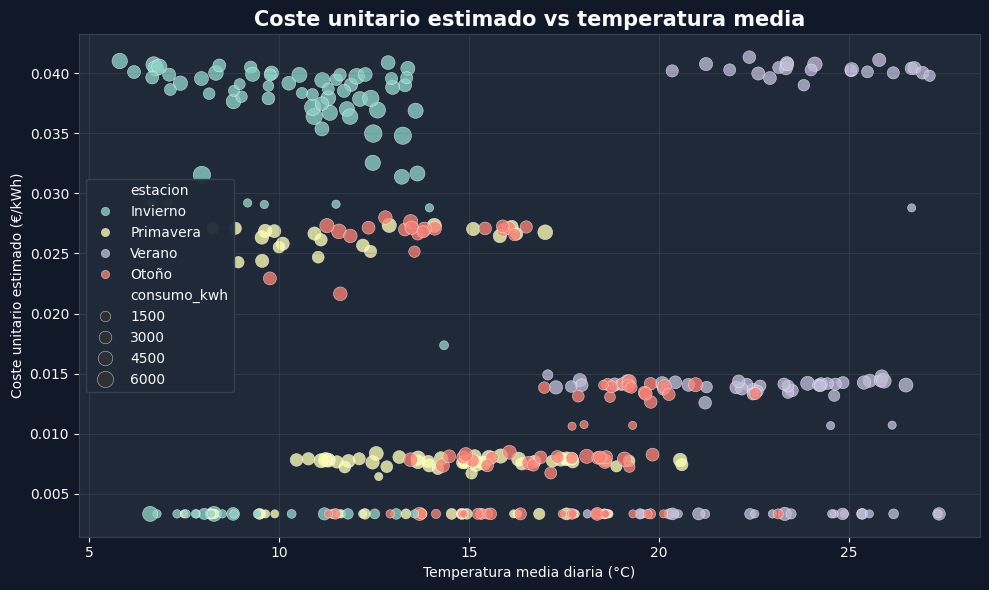

In [21]:
# ============================================================
# H1.8 - GRÁFICO: COSTE UNITARIO VS TEMPERATURA
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(COLOR_FONDO)

sns.scatterplot(
    data=df_consumo_clima,
    x="temperatura_media",
    y="coste_unitario_parcial_eur_kwh",
    hue="estacion",
    size="consumo_kwh",
    sizes=(35, 160),
    alpha=0.78,
    edgecolor="white",
    linewidth=0.35,
    ax=ax
)

aplicar_estilo(ax)

ax.set_title("Coste unitario estimado vs temperatura media", fontsize=15, weight="bold")
ax.set_xlabel("Temperatura media diaria (°C)")
ax.set_ylabel("Coste unitario estimado (€/kWh)")
ax.yaxis.set_major_formatter(FuncFormatter(formato_eur_kwh))

legend = ax.legend(facecolor=COLOR_PANEL, edgecolor="#374151", framealpha=0.95, loc="best")
plt.setp(legend.get_texts(), color=COLOR_TEXTO)
plt.setp(legend.get_title(), color=COLOR_TEXTO)

guardar_y_mostrar_grafico("h1_04_coste_unitario_temperatura_media.png")

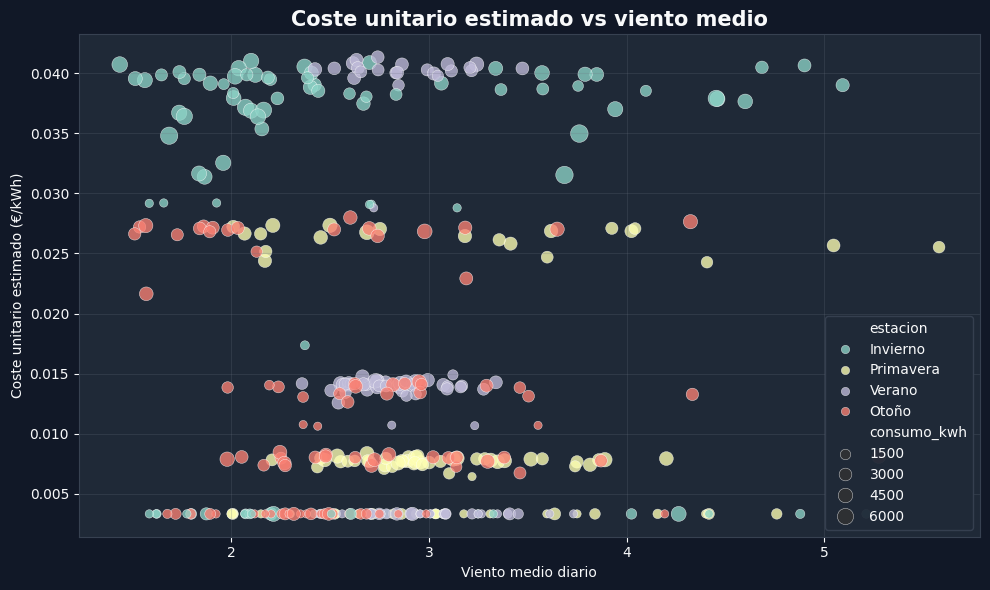

In [22]:
# ============================================================
# H1.9 - GRÁFICO: COSTE UNITARIO VS VIENTO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(COLOR_FONDO)

sns.scatterplot(
    data=df_consumo_clima,
    x="viento_medio",
    y="coste_unitario_parcial_eur_kwh",
    hue="estacion",
    size="consumo_kwh",
    sizes=(35, 160),
    alpha=0.78,
    edgecolor="white",
    linewidth=0.35,
    ax=ax
)

aplicar_estilo(ax)

ax.set_title("Coste unitario estimado vs viento medio", fontsize=15, weight="bold")
ax.set_xlabel("Viento medio diario")
ax.set_ylabel("Coste unitario estimado (€/kWh)")
ax.yaxis.set_major_formatter(FuncFormatter(formato_eur_kwh))

legend = ax.legend(facecolor=COLOR_PANEL, edgecolor="#374151", framealpha=0.95, loc="best")
plt.setp(legend.get_texts(), color=COLOR_TEXTO)
plt.setp(legend.get_title(), color=COLOR_TEXTO)

guardar_y_mostrar_grafico("h1_05_coste_unitario_viento_medio.png")

Matriz de correlación H1:


,consumo_kwh,coste_estimado_parcial_eur,coste_unitario_parcial_eur_kwh,temperatura_media,temperatura_minima,temperatura_maxima,precipitacion,viento_medio,racha_viento,horas_sol
consumo_kwh,1.000,0.756,0.527,-0.140,-0.141,-0.136,0.024,-0.021,0.009,-0.114
coste_estimado_parcial_eur,0.756,1.000,0.882,-0.239,-0.237,-0.234,-0.010,-0.083,-0.049,-0.210
coste_unitario_parcial_eur_kwh,0.527,0.882,1.000,-0.191,-0.188,-0.188,-0.052,-0.082,-0.050,-0.170
temperatura_media,-0.140,-0.239,-0.191,1.000,0.980,0.989,-0.229,-0.021,-0.077,0.655
temperatura_minima,-0.141,-0.237,-0.188,0.980,1.000,0.939,-0.106,0.037,-0.004,0.518
temperatura_maxima,-0.136,-0.234,-0.188,0.989,0.939,1.000,-0.317,-0.065,-0.131,0.741
precipitacion,0.024,-0.010,-0.052,-0.229,-0.106,-0.317,1.000,0.511,0.618,-0.615
viento_medio,-0.021,-0.083,-0.082,-0.021,0.037,-0.065,0.511,1.000,0.961,-0.101
racha_viento,0.009,-0.049,-0.050,-0.077,-0.004,-0.131,0.618,0.961,1.000,-0.240
horas_sol,-0.114,-0.210,-0.170,0.655,0.518,0.741,-0.615,-0.101,-0.240,1.000


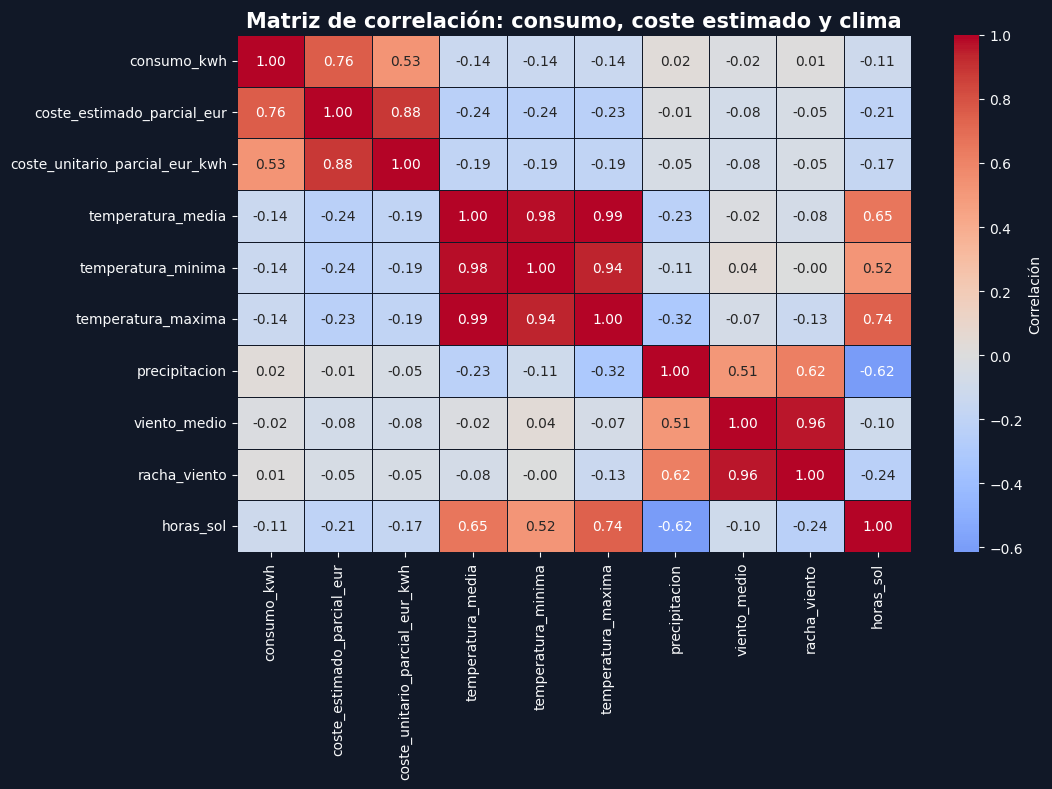

In [23]:
# ============================================================
# H1.10 - MATRIZ DE CORRELACIÓN
# ============================================================

variables_corr = [
    "consumo_kwh",
    "coste_estimado_parcial_eur",
    "coste_unitario_parcial_eur_kwh",
    "temperatura_media",
    "temperatura_minima",
    "temperatura_maxima",
    "precipitacion",
    "viento_medio",
    "racha_viento",
    "horas_sol"
]

corr_h1 = df_consumo_clima[variables_corr].corr()

print("Matriz de correlación H1:")
display(corr_h1.round(3))

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(COLOR_FONDO)

sns.heatmap(
    corr_h1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    linecolor="#111827",
    cbar_kws={"label": "Correlación"},
    ax=ax
)

ax.set_facecolor(COLOR_PANEL)
ax.set_title("Matriz de correlación: consumo, coste estimado y clima", fontsize=15, weight="bold")
ax.tick_params(colors=COLOR_TEXTO)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(COLOR_TEXTO)
cbar.ax.tick_params(colors=COLOR_TEXTO)

guardar_y_mostrar_grafico("h1_06_matriz_correlacion_consumo_coste_clima.png")

## H2. Consumo en periodos tarifarios caros

**Hipótesis:** una parte relevante del consumo puede concentrarse en periodos tarifarios caros, especialmente P1 y P2.

In [24]:
# ============================================================
# H2.1 - TABLA RESUMEN POR PERIODO TARIFARIO
# ============================================================

resumen_h2 = (
    df_maestro
    .groupby("periodo_tarifario", observed=False, as_index=False)
    .agg(
        horas=("datetime_hora", "count"),
        consumo_total_kwh=("consumo_kwh", "sum"),
        consumo_medio_horario_kwh=("consumo_kwh", "mean"),
        potencia_media_kw=("potencia_media_kw", "mean")
    )
    .sort_values("periodo_tarifario")
    .reset_index(drop=True)
)

resumen_h2["consumo_total_mwh"] = resumen_h2["consumo_total_kwh"] / 1000
resumen_h2["porcentaje_consumo"] = (
    resumen_h2["consumo_total_kwh"]
    / resumen_h2["consumo_total_kwh"].sum()
    * 100
)

print("Resumen H2:")
display(resumen_h2.round(2))

consumo_p1_p2 = resumen_h2.loc[
    resumen_h2["periodo_tarifario"].isin(["P1", "P2"]),
    "consumo_total_kwh"
].sum()

peso_p1_p2 = consumo_p1_p2 / resumen_h2["consumo_total_kwh"].sum() * 100

print("Consumo P1 + P2:", round(consumo_p1_p2, 2), "kWh")
print("Peso P1 + P2:", round(peso_p1_p2, 2), "%")

Resumen H2:


,periodo_tarifario,horas,consumo_total_kwh,consumo_medio_horario_kwh,potencia_media_kw,consumo_total_mwh,porcentaje_consumo
0,P1,801,164202.84,205.00,205.00,164.20,17.10
1,P2,1001,204694.49,204.49,204.49,204.69,21.32
2,P3,861,151053.02,175.44,175.44,151.05,15.73
3,P4,1053,191958.06,182.30,182.30,191.96,20.00
4,P5,476,88270.92,185.44,185.44,88.27,9.19
5,P6,4592,159809.24,34.80,34.80,159.81,16.65


Consumo P1 + P2: 368897.33 kWh
Peso P1 + P2: 38.43 %


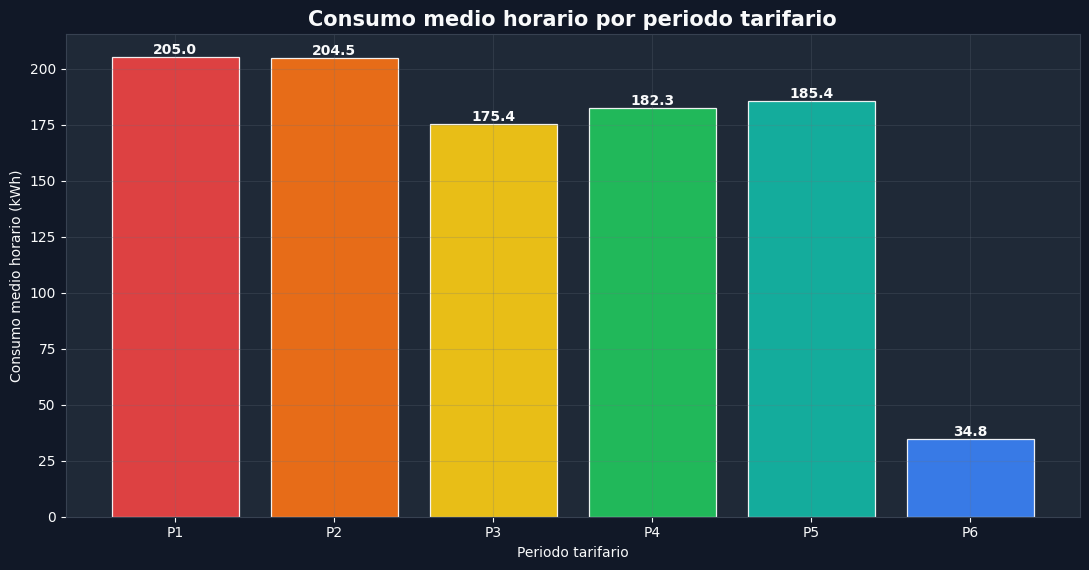

In [25]:
# ============================================================
# H2.2 - GRÁFICO: CONSUMO MEDIO HORARIO POR PERIODO
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.patch.set_facecolor(COLOR_FONDO)

colores = [
    COLORES_PERIODOS[periodo]
    for periodo in resumen_h2["periodo_tarifario"].astype(str)
]

barras = ax.bar(
    resumen_h2["periodo_tarifario"].astype(str),
    resumen_h2["consumo_medio_horario_kwh"],
    color=colores,
    edgecolor="white",
    linewidth=0.9,
    alpha=0.92
)

aplicar_estilo(ax)

ax.set_title("Consumo medio horario por periodo tarifario", fontsize=15, weight="bold")
ax.set_xlabel("Periodo tarifario")
ax.set_ylabel("Consumo medio horario (kWh)")

for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:,.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color=COLOR_TEXTO,
        weight="bold"
    )

guardar_y_mostrar_grafico("h2_03_consumo_medio_horario_por_periodo.png")

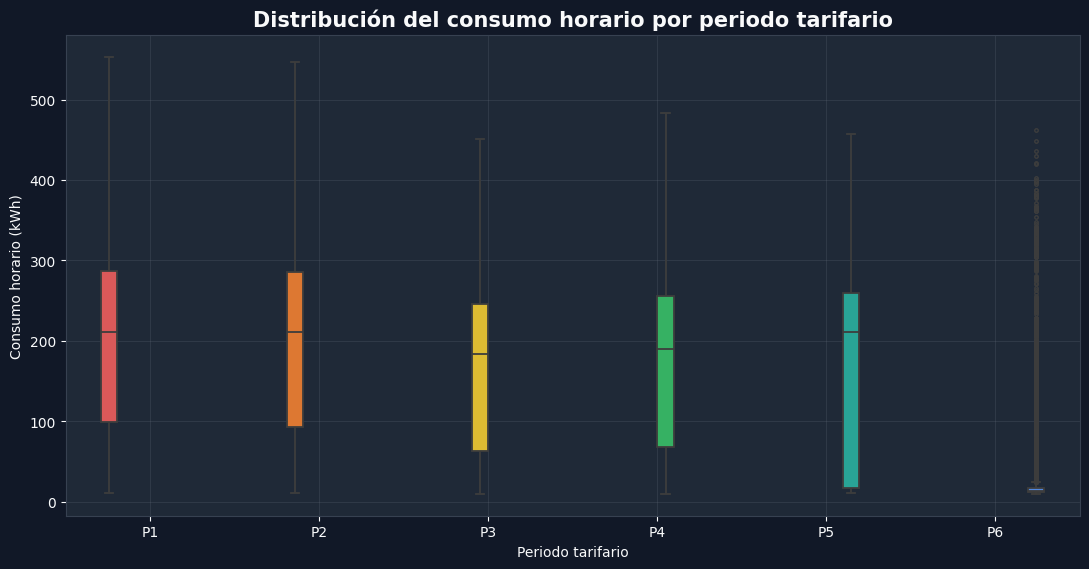

In [26]:
# ============================================================
# H2.3 - GRÁFICO: BOXPLOT CONSUMO HORARIO POR PERIODO
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.patch.set_facecolor(COLOR_FONDO)

sns.boxplot(
    data=df_maestro,
    x="periodo_tarifario",
    y="consumo_kwh",
    order=ORDEN_PERIODOS,
    hue="periodo_tarifario",
    palette=COLORES_PERIODOS,
    width=0.58,
    linewidth=1.3,
    fliersize=2.5,
    legend=False,
    ax=ax
)

aplicar_estilo(ax)

ax.set_title("Distribución del consumo horario por periodo tarifario", fontsize=15, weight="bold")
ax.set_xlabel("Periodo tarifario")
ax.set_ylabel("Consumo horario (kWh)")

guardar_y_mostrar_grafico("h2_04_boxplot_consumo_por_periodo.png")

## H3. Relación entre consumo y coste estimado

**Hipótesis:** el impacto económico del consumo no depende solo de los kWh consumidos, sino también del periodo tarifario en el que se producen.

In [27]:
# ============================================================
# H3.1 - TABLA RESUMEN ECONÓMICA POR PERIODO
# ============================================================

resumen_h3 = (
    df_maestro
    .groupby("periodo_tarifario", observed=False, as_index=False)
    .agg(
        horas=("datetime_hora", "count"),
        consumo_total_kwh=("consumo_kwh", "sum"),
        coste_estimado_total_eur=("coste_estimado_parcial_eur", "sum")
    )
    .sort_values("periodo_tarifario")
    .reset_index(drop=True)
)

resumen_h3["porcentaje_consumo"] = (
    resumen_h3["consumo_total_kwh"]
    / resumen_h3["consumo_total_kwh"].sum()
    * 100
)

resumen_h3["porcentaje_coste"] = (
    resumen_h3["coste_estimado_total_eur"]
    / resumen_h3["coste_estimado_total_eur"].sum()
    * 100
)

resumen_h3["coste_unitario_estimado_eur_kwh"] = (
    resumen_h3["coste_estimado_total_eur"]
    / resumen_h3["consumo_total_kwh"]
)

resumen_h3["diferencia_peso_coste_vs_consumo"] = (
    resumen_h3["porcentaje_coste"]
    - resumen_h3["porcentaje_consumo"]
)

print("Resumen H3:")
display(resumen_h3.round(4))

Resumen H3:


,periodo_tarifario,horas,consumo_total_kwh,coste_estimado_total_eur,porcentaje_consumo,porcentaje_coste,coste_unitario_estimado_eur_kwh,diferencia_peso_coste_vs_consumo
0,P1,801,164202.84,7578.9463,17.1047,37.4777,0.0462,20.3730
1,P2,1001,204694.49,7119.4791,21.3226,35.2056,0.0348,13.8830
2,P3,861,151053.02,2592.5230,15.7349,12.8200,0.0172,-2.9149
3,P4,1053,191958.06,1998.8593,19.9959,9.8843,0.0104,-10.1116
4,P5,476,88270.92,398.9846,9.1950,1.9730,0.0045,-7.2220
5,P6,4592,159809.24,533.7629,16.6470,2.6394,0.0033,-14.0076


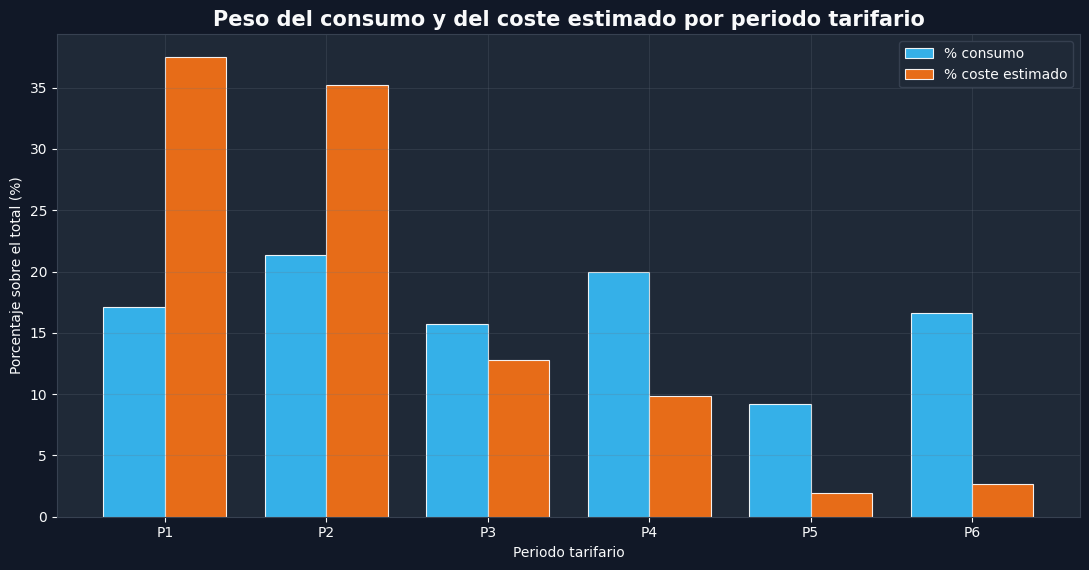

In [28]:
# ============================================================
# H3.2 - GRÁFICO: PESO DEL CONSUMO VS PESO DEL COSTE
# ============================================================

x = np.arange(len(resumen_h3))
ancho = 0.38

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.patch.set_facecolor(COLOR_FONDO)

barras_consumo = ax.bar(
    x - ancho / 2,
    resumen_h3["porcentaje_consumo"],
    width=ancho,
    label="% consumo",
    color=COLOR_CONSUMO,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.92
)

barras_coste = ax.bar(
    x + ancho / 2,
    resumen_h3["porcentaje_coste"],
    width=ancho,
    label="% coste estimado",
    color=COLOR_COSTE,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.92
)

aplicar_estilo(ax)

ax.set_title("Peso del consumo y del coste estimado por periodo tarifario", fontsize=15, weight="bold")
ax.set_xlabel("Periodo tarifario")
ax.set_ylabel("Porcentaje sobre el total (%)")
ax.set_xticks(x)
ax.set_xticklabels(resumen_h3["periodo_tarifario"].astype(str))

legend = ax.legend(facecolor=COLOR_PANEL, edgecolor="#374151", framealpha=0.95)
plt.setp(legend.get_texts(), color=COLOR_TEXTO)

guardar_y_mostrar_grafico("h3_01_peso_consumo_vs_coste_por_periodo.png")

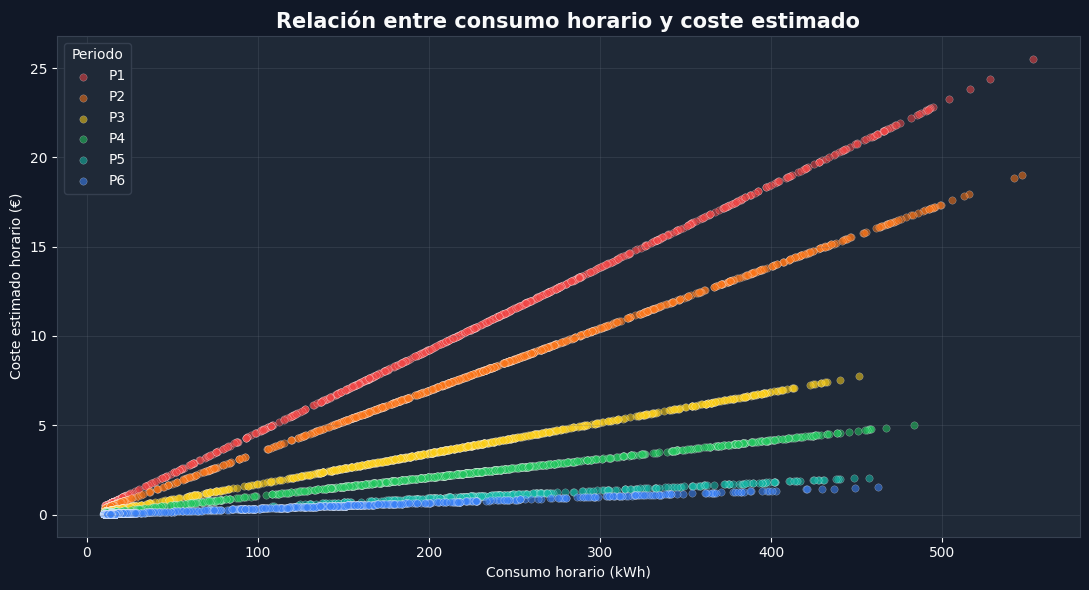

In [29]:
# ============================================================
# H3.3 - GRÁFICO: SCATTER CONSUMO HORARIO VS COSTE ESTIMADO
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COLOR_FONDO)

for periodo in ORDEN_PERIODOS:
    datos = df_maestro[df_maestro["periodo_tarifario"] == periodo]
    ax.scatter(
        datos["consumo_kwh"],
        datos["coste_estimado_parcial_eur"],
        s=28,
        alpha=0.55,
        color=COLORES_PERIODOS[periodo],
        edgecolors="white",
        linewidths=0.25,
        label=periodo
    )

aplicar_estilo(ax)

ax.set_title("Relación entre consumo horario y coste estimado", fontsize=15, weight="bold")
ax.set_xlabel("Consumo horario (kWh)")
ax.set_ylabel("Coste estimado horario (€)")

legend = ax.legend(title="Periodo", facecolor=COLOR_PANEL, edgecolor="#374151", framealpha=0.95)
plt.setp(legend.get_texts(), color=COLOR_TEXTO)
plt.setp(legend.get_title(), color=COLOR_TEXTO)

guardar_y_mostrar_grafico("h3_02_scatter_consumo_vs_coste_parcial.png")

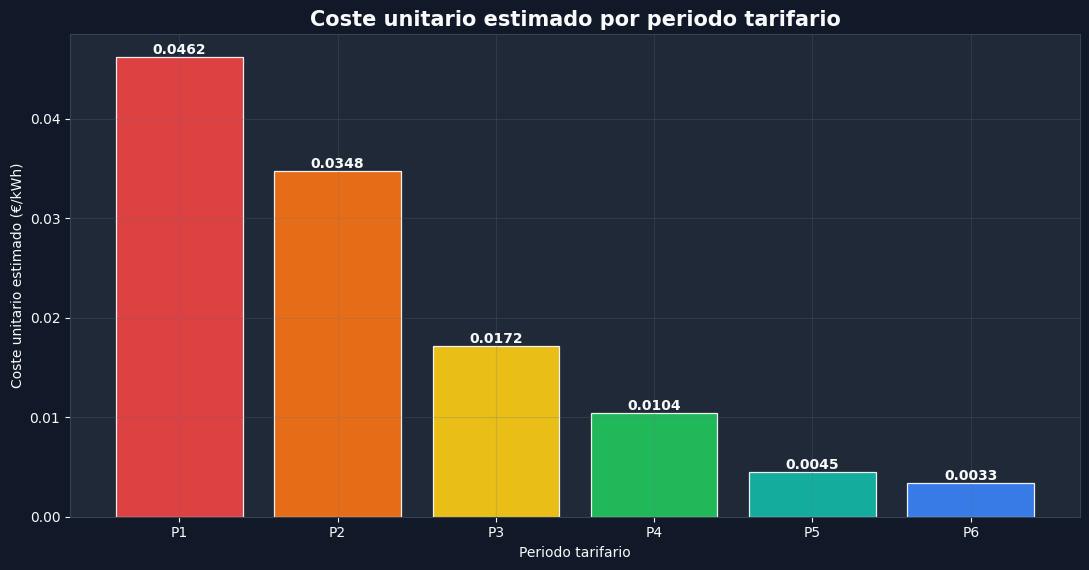

In [30]:
# ============================================================
# H3.4 - GRÁFICO: COSTE UNITARIO ESTIMADO POR PERIODO
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.patch.set_facecolor(COLOR_FONDO)

colores = [
    COLORES_PERIODOS[periodo]
    for periodo in resumen_h3["periodo_tarifario"].astype(str)
]

barras = ax.bar(
    resumen_h3["periodo_tarifario"].astype(str),
    resumen_h3["coste_unitario_estimado_eur_kwh"],
    color=colores,
    edgecolor="white",
    linewidth=0.9,
    alpha=0.92
)

aplicar_estilo(ax)

ax.set_title("Coste unitario estimado por periodo tarifario", fontsize=15, weight="bold")
ax.set_xlabel("Periodo tarifario")
ax.set_ylabel("Coste unitario estimado (€/kWh)")

for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color=COLOR_TEXTO,
        weight="bold"
    )

guardar_y_mostrar_grafico("h3_03_coste_unitario_parcial_por_periodo.png")

## H4. Impacto de adelantar dos horas el consumo

**Hipótesis:** el cambio de turnos u horarios de trabajo puede afectar al coste energético estimado de la planta.

Se simula que el patrón de consumo se adelanta dos horas usando `shift(-2)`.

In [31]:
# ============================================================
# H4.1 - CREACIÓN DEL ESCENARIO ADELANTANDO 2 HORAS
# ============================================================

df_h4 = (
    df_maestro
    .sort_values("datetime_hora")
    .reset_index(drop=True)
    .copy()
)

# Adelantar 2 horas:
# la fila actual toma el consumo de dos horas después.
df_h4["consumo_escenario_2h"] = df_h4["consumo_kwh"].shift(-2)

# Cerramos el ciclo anual con los dos primeros consumos del año.
df_h4.loc[df_h4.index[-2:], "consumo_escenario_2h"] = (
    df_h4["consumo_kwh"].iloc[:2].values
)

df_h4["coste_actual_eur"] = (
    df_h4["consumo_kwh"]
    * df_h4["precio_variable_parcial_eur_kwh"]
)

df_h4["coste_escenario_2h_eur"] = (
    df_h4["consumo_escenario_2h"]
    * df_h4["precio_variable_parcial_eur_kwh"]
)

df_h4["diferencia_coste_2h_eur"] = (
    df_h4["coste_escenario_2h_eur"]
    - df_h4["coste_actual_eur"]
)

coste_actual_total = df_h4["coste_actual_eur"].sum()
coste_escenario_2h_total = df_h4["coste_escenario_2h_eur"].sum()
diferencia_total_eur = coste_escenario_2h_total - coste_actual_total
porcentaje_variacion = diferencia_total_eur / coste_actual_total * 100

print("Coste actual estimado:", round(coste_actual_total, 2), "€")
print("Coste escenario adelanto 2h:", round(coste_escenario_2h_total, 2), "€")
print("Diferencia:", round(diferencia_total_eur, 2), "€")
print("Variación porcentual:", round(porcentaje_variacion, 2), "%")

print("\nValidación de consumo total:")
print("Consumo actual:", round(df_h4["consumo_kwh"].sum(), 2))
print("Consumo escenario:", round(df_h4["consumo_escenario_2h"].sum(), 2))
print("Diferencia:", round(df_h4["consumo_escenario_2h"].sum() - df_h4["consumo_kwh"].sum(), 6))

display(df_h4[["datetime_hora", "periodo_tarifario", "consumo_kwh", "consumo_escenario_2h", "coste_actual_eur", "coste_escenario_2h_eur"]].head(10))

Coste actual estimado: 20222.56 €
Coste escenario adelanto 2h: 17973.93 €
Diferencia: -2248.63 €
Variación porcentual: -11.12 %

Validación de consumo total:
Consumo actual: 959988.57
Consumo escenario: 959988.57
Diferencia: 0.0


,datetime_hora,periodo_tarifario,consumo_kwh,consumo_escenario_2h,coste_actual_eur,coste_escenario_2h_eur
0,2024-01-01 00:00:00,P6,13.83,14.12,0.046192,0.047161
1,2024-01-01 01:00:00,P6,14.01,13.82,0.046793,0.046159
2,2024-01-01 02:00:00,P6,14.12,14.47,0.047161,0.048330
3,2024-01-01 03:00:00,P6,13.82,13.71,0.046159,0.045791
4,2024-01-01 04:00:00,P6,14.47,14.26,0.048330,0.047628
5,2024-01-01 05:00:00,P6,13.71,13.64,0.045791,0.045558
6,2024-01-01 06:00:00,P6,14.26,13.86,0.047628,0.046292
7,2024-01-01 07:00:00,P6,13.64,15.44,0.045558,0.051570
8,2024-01-01 08:00:00,P2,13.86,15.02,0.482065,0.522411
9,2024-01-01 09:00:00,P1,15.44,15.16,0.712649,0.699725


In [32]:
# ============================================================
# H4.2 - RESUMEN POR TURNO
# ============================================================

resumen_turno_h4 = (
    df_h4
    .groupby("turno", observed=False, as_index=False)
    .agg(
        consumo_medio_horario_kwh=("consumo_kwh", "mean"),
        consumo_total_kwh=("consumo_kwh", "sum"),
        coste_actual_total_eur=("coste_actual_eur", "sum"),
        coste_escenario_2h_total_eur=("coste_escenario_2h_eur", "sum")
    )
    .sort_values("turno")
    .reset_index(drop=True)
)

resumen_turno_h4["ahorro_escenario_2h_eur"] = (
    resumen_turno_h4["coste_actual_total_eur"]
    - resumen_turno_h4["coste_escenario_2h_total_eur"]
)

print("Resumen H4 por turno:")
display(resumen_turno_h4.round(2))

Resumen H4 por turno:


,turno,consumo_medio_horario_kwh,consumo_total_kwh,coste_actual_total_eur,coste_escenario_2h_total_eur,ahorro_escenario_2h_eur
0,M,137.38,402252.72,9390.67,10142.29,-751.61
1,T,166.54,487630.20,10125.25,7236.34,2888.91
2,N,23.94,70105.65,706.63,595.30,111.33


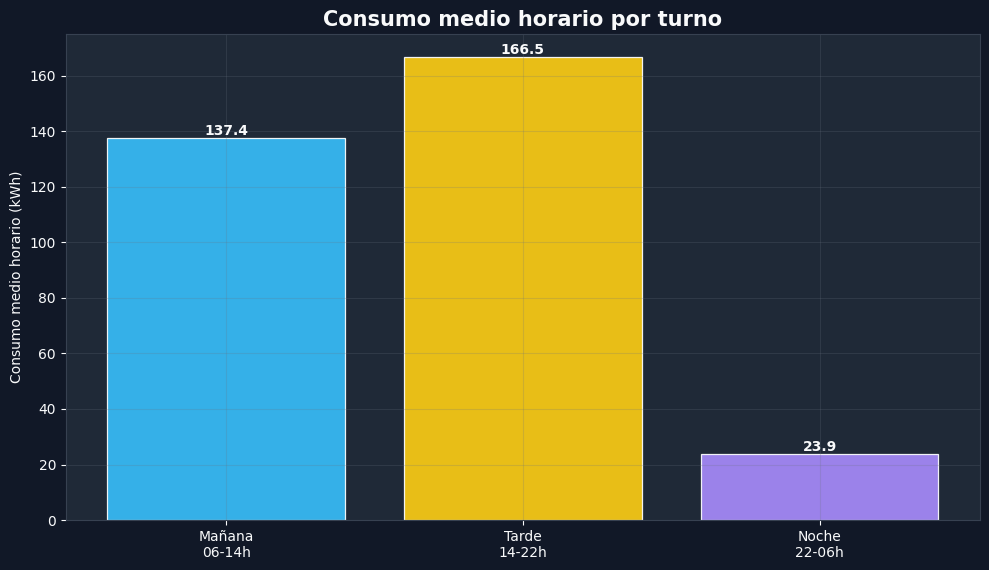

In [33]:
# ============================================================
# H4.3 - GRÁFICO: CONSUMO MEDIO POR TURNO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.8))
fig.patch.set_facecolor(COLOR_FONDO)

barras = ax.bar(
    resumen_turno_h4["turno"].astype(str).map(ETIQUETAS_TURNOS),
    resumen_turno_h4["consumo_medio_horario_kwh"],
    color=[COLORES_TURNOS[t] for t in resumen_turno_h4["turno"].astype(str)],
    edgecolor="white",
    linewidth=0.9,
    alpha=0.92
)

aplicar_estilo(ax)

ax.set_title("Consumo medio horario por turno", fontsize=15, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Consumo medio horario (kWh)")

for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:,.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color=COLOR_TEXTO,
        weight="bold"
    )

guardar_y_mostrar_grafico("h4_01_consumo_medio_por_turno.png")

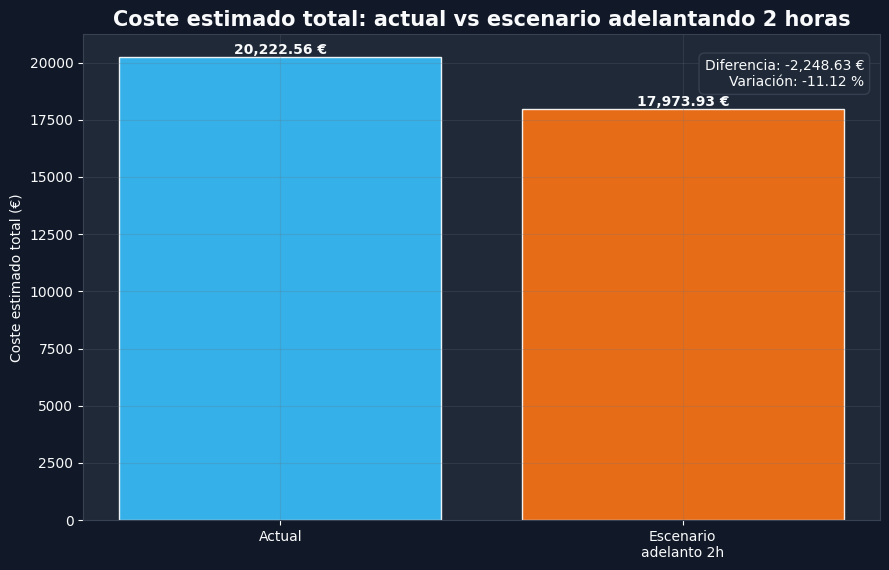

In [34]:
# ============================================================
# H4.4 - GRÁFICO: COSTE ACTUAL VS ESCENARIO ADELANTANDO 2H
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5.8))
fig.patch.set_facecolor(COLOR_FONDO)

categorias = ["Actual", "Escenario\nadelanto 2h"]
valores = [coste_actual_total, coste_escenario_2h_total]

barras = ax.bar(
    categorias,
    valores,
    color=[COLOR_CONSUMO, COLOR_COSTE],
    edgecolor="white",
    linewidth=1,
    alpha=0.92
)

aplicar_estilo(ax)

ax.set_title("Coste estimado total: actual vs escenario adelantando 2 horas", fontsize=15, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Coste estimado total (€)")

for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:,.2f} €",
        ha="center",
        va="bottom",
        fontsize=10,
        color=COLOR_TEXTO,
        weight="bold"
    )

texto_resultado = (
    f"Diferencia: {diferencia_total_eur:,.2f} €\n"
    f"Variación: {porcentaje_variacion:.2f} %"
)

ax.text(
    0.98,
    0.95,
    texto_resultado,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color=COLOR_TEXTO,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor=COLOR_PANEL,
        edgecolor="#374151",
        alpha=0.95
    )
)

guardar_y_mostrar_grafico("h4_02_coste_actual_vs_escenario_2h.png")

Resumen H4 por periodo:


,periodo_tarifario,coste_actual_total_eur,coste_escenario_2h_total_eur,diferencia_coste_eur
0,P1,7578.95,6544.74,-1034.20
1,P2,7119.48,6287.75,-831.73
2,P3,2592.52,2202.37,-390.15
3,P4,1998.86,1679.99,-318.87
4,P5,398.98,373.72,-25.26
5,P6,533.76,885.34,351.58


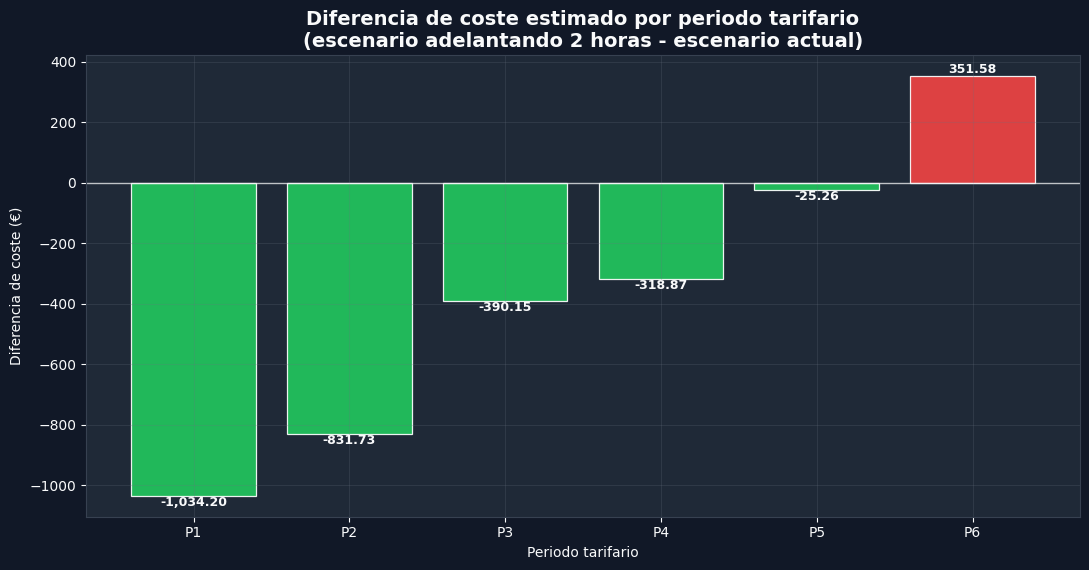

In [35]:
# ============================================================
# H4.5 - GRÁFICO: DIFERENCIA DE COSTE POR PERIODO
# ============================================================

resumen_periodo_h4 = (
    df_h4
    .groupby("periodo_tarifario", observed=False, as_index=False)
    .agg(
        coste_actual_total_eur=("coste_actual_eur", "sum"),
        coste_escenario_2h_total_eur=("coste_escenario_2h_eur", "sum")
    )
    .sort_values("periodo_tarifario")
    .reset_index(drop=True)
)

resumen_periodo_h4["diferencia_coste_eur"] = (
    resumen_periodo_h4["coste_escenario_2h_total_eur"]
    - resumen_periodo_h4["coste_actual_total_eur"]
)

print("Resumen H4 por periodo:")
display(resumen_periodo_h4.round(2))

fig, ax = plt.subplots(figsize=(11, 5.8))
fig.patch.set_facecolor(COLOR_FONDO)

colores_diferencia = [
    "#ef4444" if valor > 0 else "#22c55e"
    for valor in resumen_periodo_h4["diferencia_coste_eur"]
]

barras = ax.bar(
    resumen_periodo_h4["periodo_tarifario"].astype(str),
    resumen_periodo_h4["diferencia_coste_eur"],
    color=colores_diferencia,
    edgecolor="white",
    linewidth=0.9,
    alpha=0.92
)

aplicar_estilo(ax)
ax.axhline(0, color="white", linewidth=1, alpha=0.7)

ax.set_title(
    "Diferencia de coste estimado por periodo tarifario\n"
    "(escenario adelantando 2 horas - escenario actual)",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Periodo tarifario")
ax.set_ylabel("Diferencia de coste (€)")

for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{altura:,.2f}",
        ha="center",
        va="bottom" if altura >= 0 else "top",
        fontsize=9,
        color=COLOR_TEXTO,
        weight="bold"
    )

guardar_y_mostrar_grafico("h4_03_diferencia_coste_por_periodo_escenario_2h.png")

## Validación final del notebook de pruebas

Comprobamos que los principales datasets y gráficos se han generado correctamente.

In [36]:
# ============================================================
# VALIDACIÓN FINAL DE ARCHIVOS GENERADOS
# ============================================================

graficos_esperados = [
    "h1_01_consumo_diario_temperatura_media.png",
    "h1_02_scatter_consumo_temperatura_media.png",
    "h1_03_consumo_coste_por_tipo_temperatura.png",
    "h1_04_coste_unitario_temperatura_media.png",
    "h1_05_coste_unitario_viento_medio.png",
    "h1_06_matriz_correlacion_consumo_coste_clima.png",
    "h2_03_consumo_medio_horario_por_periodo.png",
    "h2_04_boxplot_consumo_por_periodo.png",
    "h3_01_peso_consumo_vs_coste_por_periodo.png",
    "h3_02_scatter_consumo_vs_coste_parcial.png",
    "h3_03_coste_unitario_parcial_por_periodo.png",
    "h4_01_consumo_medio_por_turno.png",
    "h4_02_coste_actual_vs_escenario_2h.png",
    "h4_03_diferencia_coste_por_periodo_escenario_2h.png"
]

print("Comprobación de gráficos:")
for grafico in graficos_esperados:
    ruta = ruta_graficos / grafico
    estado = "OK" if ruta.exists() else "NO ENCONTRADO"
    print(f"{estado}: {grafico}")

ruta_consumo_clima = ruta_data_limpios / "df_consumo_clima_limpio.csv"
print("\nDataset df_consumo_clima_limpio.csv:", "OK" if ruta_consumo_clima.exists() else "NO ENCONTRADO")

print("\nResumen final:")
print("df_maestro:", df_maestro.shape)
print("df_consumo_clima:", df_consumo_clima.shape)
print("Consumo total df_maestro:", round(df_maestro["consumo_kwh"].sum(), 2))
print("Consumo total df_consumo_clima:", round(df_consumo_clima["consumo_kwh"].sum(), 2))
print("Diferencia consumo:", round(df_consumo_clima["consumo_kwh"].sum() - df_maestro["consumo_kwh"].sum(), 6))

Comprobación de gráficos:
OK: h1_01_consumo_diario_temperatura_media.png
OK: h1_02_scatter_consumo_temperatura_media.png
OK: h1_03_consumo_coste_por_tipo_temperatura.png
OK: h1_04_coste_unitario_temperatura_media.png
OK: h1_05_coste_unitario_viento_medio.png
OK: h1_06_matriz_correlacion_consumo_coste_clima.png
OK: h2_03_consumo_medio_horario_por_periodo.png
OK: h2_04_boxplot_consumo_por_periodo.png
OK: h3_01_peso_consumo_vs_coste_por_periodo.png
OK: h3_02_scatter_consumo_vs_coste_parcial.png
OK: h3_03_coste_unitario_parcial_por_periodo.png
OK: h4_01_consumo_medio_por_turno.png
OK: h4_02_coste_actual_vs_escenario_2h.png
OK: h4_03_diferencia_coste_por_periodo_escenario_2h.png

Dataset df_consumo_clima_limpio.csv: OK

Resumen final:
df_maestro: (8784, 36)
df_consumo_clima: (366, 28)
Consumo total df_maestro: 959988.57
Consumo total df_consumo_clima: 959988.57
Diferencia consumo: 0.0


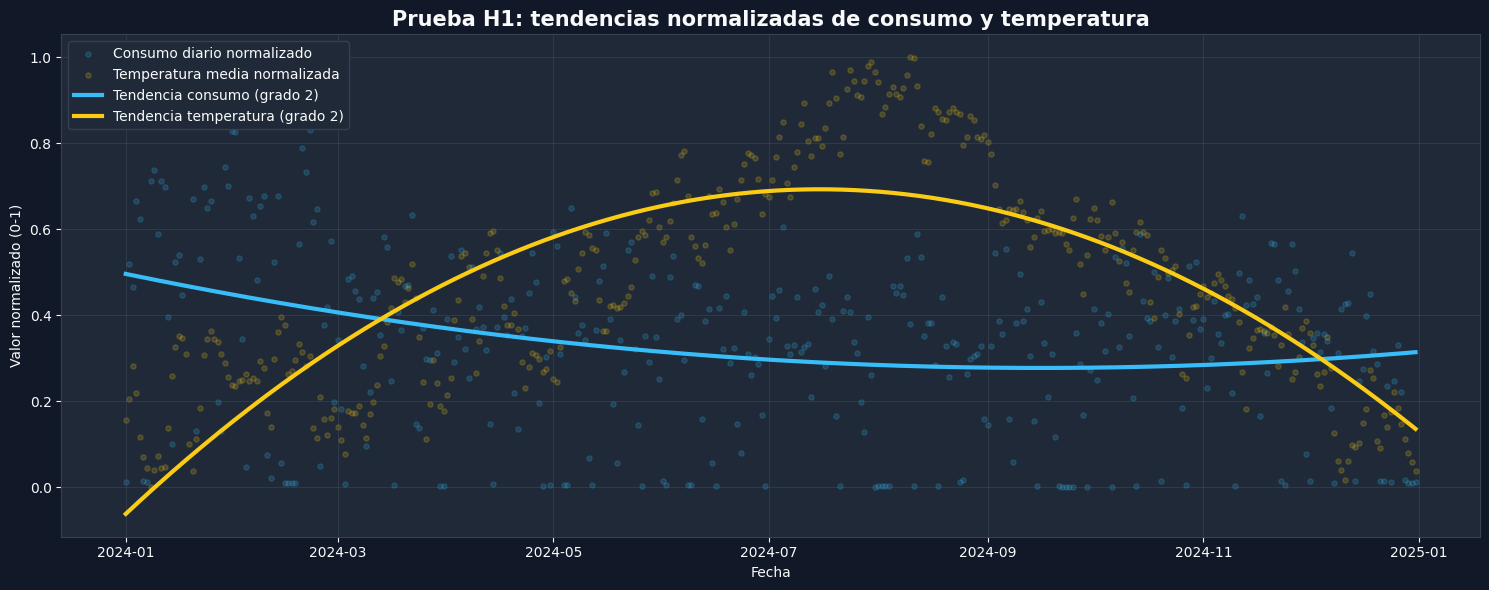

In [38]:
# ============================================================
# PRUEBA H1_01 - CONSUMO Y TEMPERATURA CON CURVAS DE GRADO 2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. CARGA DE DATOS
# ============================================================

ruta_data_limpios = Path(r"..\data_limpios")
ruta_graficos = Path(r"..\graficos")
ruta_graficos.mkdir(parents=True, exist_ok=True)

df_consumo_clima = pd.read_csv(
    ruta_data_limpios / "df_consumo_clima_limpio.csv"
)

df_consumo_clima["fecha"] = pd.to_datetime(df_consumo_clima["fecha"])


# ============================================================
# 2. PREPARACIÓN DE DATOS
# ============================================================

df_h1 = df_consumo_clima.copy()

# Creamos una variable numérica para representar el paso del tiempo
df_h1["dia_indice"] = np.arange(len(df_h1))

# Normalizamos consumo y temperatura entre 0 y 1
df_h1["consumo_norm"] = (
    (df_h1["consumo_kwh"] - df_h1["consumo_kwh"].min()) /
    (df_h1["consumo_kwh"].max() - df_h1["consumo_kwh"].min())
)

df_h1["temperatura_norm"] = (
    (df_h1["temperatura_media"] - df_h1["temperatura_media"].min()) /
    (df_h1["temperatura_media"].max() - df_h1["temperatura_media"].min())
)


# ============================================================
# 3. AJUSTE POLINÓMICO DE GRADO 2
# ============================================================

x = df_h1["dia_indice"]

coef_consumo = np.polyfit(x, df_h1["consumo_norm"], 2)
coef_temperatura = np.polyfit(x, df_h1["temperatura_norm"], 2)

poly_consumo = np.poly1d(coef_consumo)
poly_temperatura = np.poly1d(coef_temperatura)

x_suave = np.linspace(x.min(), x.max(), 500)

y_consumo_suave = poly_consumo(x_suave)
y_temperatura_suave = poly_temperatura(x_suave)

fechas_suaves = pd.date_range(
    start=df_h1["fecha"].min(),
    end=df_h1["fecha"].max(),
    periods=len(x_suave)
)


# ============================================================
# 4. CONFIGURACIÓN VISUAL
# ============================================================

plt.style.use("dark_background")

COLOR_FONDO = "#111827"
COLOR_PANEL = "#1f2937"
COLOR_TEXTO = "#f9fafb"
COLOR_GRID = "#6b7280"

COLOR_CONSUMO = "#38bdf8"
COLOR_TEMP = "#facc15"


# ============================================================
# 5. GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(COLOR_FONDO)
ax.set_facecolor(COLOR_PANEL)

# Datos reales suavemente visibles de fondo
ax.scatter(
    df_h1["fecha"],
    df_h1["consumo_norm"],
    s=14,
    alpha=0.18,
    color=COLOR_CONSUMO,
    label="Consumo diario normalizado"
)

ax.scatter(
    df_h1["fecha"],
    df_h1["temperatura_norm"],
    s=14,
    alpha=0.18,
    color=COLOR_TEMP,
    label="Temperatura media normalizada"
)

# Curvas de regresión polinómica grado 2
ax.plot(
    fechas_suaves,
    y_consumo_suave,
    color=COLOR_CONSUMO,
    linewidth=3,
    label="Tendencia consumo (grado 2)"
)

ax.plot(
    fechas_suaves,
    y_temperatura_suave,
    color=COLOR_TEMP,
    linewidth=3,
    label="Tendencia temperatura (grado 2)"
)

ax.set_title(
    "Prueba H1: tendencias normalizadas de consumo y temperatura",
    fontsize=15,
    weight="bold",
    color=COLOR_TEXTO
)

ax.set_xlabel("Fecha", color=COLOR_TEXTO)
ax.set_ylabel("Valor normalizado (0-1)", color=COLOR_TEXTO)

ax.grid(True, alpha=0.22, color=COLOR_GRID)
ax.tick_params(colors=COLOR_TEXTO)

for spine in ax.spines.values():
    spine.set_color("#374151")

legend = ax.legend(
    facecolor=COLOR_PANEL,
    edgecolor="#374151",
    framealpha=0.95,
    loc="upper left"
)

plt.setp(legend.get_texts(), color=COLOR_TEXTO)

plt.tight_layout()

plt.savefig(
    ruta_graficos / "prueba_h1_01_regresion_grado2_consumo_temperatura.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()